In [50]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(-1)
pl.Config.set_decimal_separator(',')
pl.Config.set_thousands_separator('.')
pl.Config.set_float_precision(2)

DATA_SOURCE_1 = './../../DATA/Bolsa_Familia/'
DATA_SOURCE_2 = './../../DATA/TSE/'

##### Obtendo os dados e filtrando os registros 13 e 22

In [51]:
try:
    print('\nLendo os dados...')

    df_dados_bolsa = pl.scan_parquet(DATA_SOURCE_1 + 'bolsa_familia.parquet')
    print(df_dados_bolsa.columns)

    df_dados_votacao = pl.read_csv(DATA_SOURCE_2 + 'votacao_secao_2022_BR.csv', separator=';', encoding='iso-8859-1')
    print(df_dados_votacao.columns)

    # filtrar para segundo turno 'NR_TURNO' == 2 e 'NR_VOTAVEL' 13 e 22
    df_dados_votacao_turno2 = df_dados_votacao.filter(
        (pl.col('NR_TURNO') == 2) & 
        (pl.col('NR_VOTAVEL').is_in ([13, 22]))
    )


except Exception as e:
    print(f'\nErro ao ler os dados: {e}')


Lendo os dados...
['MÊS COMPETÊNCIA', 'MÊS REFERÊNCIA', 'UF', 'CÓDIGO MUNICÍPIO SIAFI', 'NOME MUNICÍPIO', 'CPF FAVORECIDO', 'NIS FAVORECIDO', 'NOME FAVORECIDO', 'VALOR PARCELA']


C:\Users\jairo.temerozo\AppData\Local\Temp\ipykernel_30980\129079265.py:5: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(df_dados_bolsa.columns)


['DT_GERACAO', 'HH_GERACAO', 'ANO_ELEICAO', 'CD_TIPO_ELEICAO', 'NM_TIPO_ELEICAO', 'NR_TURNO', 'CD_ELEICAO', 'DS_ELEICAO', 'DT_ELEICAO', 'TP_ABRANGENCIA', 'SG_UF', 'SG_UE', 'NM_UE', 'CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'CD_CARGO', 'DS_CARGO', 'NR_VOTAVEL', 'NM_VOTAVEL', 'QT_VOTOS', 'NR_LOCAL_VOTACAO', 'SQ_CANDIDATO', 'NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO']


##### Processando votação

In [52]:
# Processamento votação

try:

    # Delimitar as variáveis 'SG_UF', 'NR_VOTAVEL', 'QT_VOTOS'
    df_votacao = df_dados_votacao_turno2.lazy().select(['SG_UF', 'NM_VOTAVEL', 'QT_VOTOS'])

    # Converter Categorical
    df_votacao = df_votacao.with_columns([
        pl.col('SG_UF').cast(pl.Categorical),
        pl.col('NM_VOTAVEL').cast(pl.Categorical)
    ])

    # Agrupar por 'SG_UF' e 'NM_VOTAVEL' e somar 'QT_VOTOS'
    df_votacao = (df_votacao
        .group_by(['SG_UF', 'NM_VOTAVEL'])
        .agg(pl.sum('QT_VOTOS').alias('QT_VOTOS_TOTAL'))
        .sort(['SG_UF', 'NM_VOTAVEL'])
    )

    # coletar os dados

    # df_votacao = df_votacao.collect()
    # display(df_votacao)

except Exception as e:
    print(f'Erro ao processar os dados: {e}')

##### Processando Bolsa Familia

In [53]:
# processamento bolsa familia

try:
    # delimitar as variáveis, converter categorical, agrupar e totalizar

    # delimitando as variáveis 'UF', 'VALOR PARCELA'
    df_bolsa_familia = df_dados_bolsa.lazy().select(['UF', 'VALOR PARCELA'])    

    # converter categorical
    df_bolsa_familia = df_bolsa_familia.with_columns([
        pl.col('UF').cast(pl.Categorical)
    ])

    # agrupar por 'UF' e somar 'VALOR PARCELA'
    df_bolsa_familia = (df_bolsa_familia
        .group_by('UF')
        .agg(pl.sum('VALOR PARCELA').alias('VALOR_TOTAL'))
        .sort('UF')
    )

    # coletar os dados
    # df_bolsa_familia = df_bolsa_familia.collect()
    # display(df_bolsa_familia)

except Exception as e:
    print(f'Erro ao processar os dados: {e}')

##### Juntando os dados

In [54]:
# Realizando o merge dos dois dataframes

try:
    # no polars => Join() | no pandas => merge()
    df_votos_bolsa_familia = (
        df_votacao.join(df_bolsa_familia, left_on='SG_UF', right_on='UF')
    )

    df_votos_bolsa_familia = df_votos_bolsa_familia.collect().sort(['VALOR_TOTAL'], descending=True)
    display(df_votos_bolsa_familia)


except Exception as e:
    print(f'Erro ao realizar o merge dos dados: {e}')

SG_UF,NM_VOTAVEL,QT_VOTOS_TOTAL,VALOR_TOTAL
cat,cat,i64,f64
"""BA""","""LUIZ INÁCIO LULA DA SILVA""",6.097.815,"7.775.720.895,00"
"""BA""","""JAIR MESSIAS BOLSONARO""",2.357.028,"7.775.720.895,00"
"""SP""","""LUIZ INÁCIO LULA DA SILVA""",11.519.882,"7.450.021.108,00"
"""SP""","""JAIR MESSIAS BOLSONARO""",14.216.587,"7.450.021.108,00"
"""PE""","""LUIZ INÁCIO LULA DA SILVA""",3.640.933,"4.945.106.688,00"
"""PE""","""JAIR MESSIAS BOLSONARO""",1.798.832,"4.945.106.688,00"
"""MG""","""JAIR MESSIAS BOLSONARO""",6.141.310,"4.755.366.777,00"
"""MG""","""LUIZ INÁCIO LULA DA SILVA""",6.190.960,"4.755.366.777,00"
"""RJ""","""JAIR MESSIAS BOLSONARO""",5.403.894,"4.740.470.130,00"


#### Correlação entre os dados

In [55]:
# verificando a correlação entre as variáveis 'QT_VOTOS_TOTAL' e 'VALOR_TOTAL'

try:
    dict_correlacoes = {} # guardar a correlação de cada candidato

    for candidato in df_votos_bolsa_familia['NM_VOTAVEL'].unique():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)
        
    #criar arrays numpy 'VALOR PARCELA' e 'QT_VOTOS_TOTAL'
        
        array_votos = np.array(df_candidato['QT_VOTOS_TOTAL'])
        array_bolsa_familia = np.array(df_candidato['VALOR_TOTAL'])

    # calcular correlação
        correlacao = np.corrcoef(array_votos, array_bolsa_familia)[0, 1]

        dict_correlacoes[candidato] = correlacao

        print(f'Correlação entre votos e bolsa família para {candidato}: {correlacao:.4f}')    

    print('Correlação calculada...')

except Exception as e:
    print(f'Erro ao calcular a correlação: {e}')

Correlação entre votos e bolsa família para JAIR MESSIAS BOLSONARO: 0.6328
Correlação entre votos e bolsa família para LUIZ INÁCIO LULA DA SILVA: 0.8908
Correlação calculada...


#### Visualizando os dados

Plotando os gráficos...


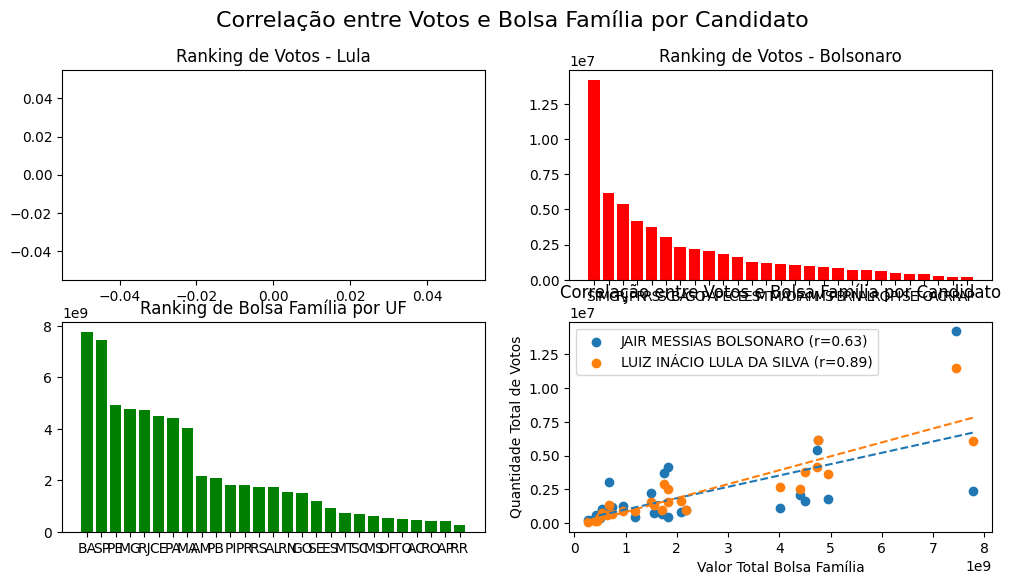

In [64]:
# visualização dos dados

try:
    print('Plotando os gráficos...')

    plt.subplots(2, 2, figsize=(12, 6))
    plt.suptitle('Correlação entre Votos e Bolsa Família por Candidato', fontsize=16)

    # Posição 1: Ranking Lula
    plt.subplot(2, 2, 1)
    df_lula = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'LUIS INÁCIO LULA DA SILVA')
    df_lula = df_lula.sort('QT_VOTOS_TOTAL', descending=True)

    # Gráfico de barras para Lula
    plt.bar(df_lula['SG_UF'], df_lula['QT_VOTOS_TOTAL'], color='blue')
    plt.title('Ranking de Votos - Lula')

    # Posição 2: Ranking Bolsonaro

    plt.subplot(2, 2, 2)
    df_bolsonaro = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'JAIR MESSIAS BOLSONARO')
    df_bolsonaro = df_bolsonaro.sort('QT_VOTOS_TOTAL', descending=True)

    # Gráfico de barras para Bolsonaro
    plt.bar(df_bolsonaro['SG_UF'], df_bolsonaro['QT_VOTOS_TOTAL'], color='red')
    plt.title('Ranking de Votos - Bolsonaro')

    # posição 3: ranking bolsa familia
    plt.subplot(2, 2, 3)
    plt.title('Ranking de Bolsa Família por UF')

    # gráfico de colunas
    df_bolsa_familia = df_bolsa_familia.sort('VALOR_TOTAL', descending=True)
    plt.bar(df_bolsa_familia['UF'], df_bolsa_familia['VALOR_TOTAL'], color='green')

    # posição 4: correlação entre votos e bolsa familia
    plt.subplot(2, 2, 4)
    plt.title('Correlação entre Votos e Bolsa Família por Candidato')

    # gráfico de dispersão
    for candidato, correlacao in dict_correlacoes.items():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)
        plt.scatter(df_candidato['VALOR_TOTAL'], df_candidato['QT_VOTOS_TOTAL'], label=f'{candidato} (r={correlacao:.2f})') 
        # adicionar legenda
    plt.xlabel('Valor Total Bolsa Família')
    plt.ylabel('Quantidade Total de Votos')
    plt.legend()
        # adicionar linha de tendência
    for candidato in df_votos_bolsa_familia['NM_VOTAVEL'].unique():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)
        x = np.array(df_candidato['VALOR_TOTAL'])
        y = np.array(df_candidato['QT_VOTOS_TOTAL'])
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m*x + b, label=f'Tendência {candidato}', linestyle='--')


    

    plt.tight_layout
    plt.show()

except Exception as e:
    print(f'Erro ao visualizar os dados: {e}')